# 🚀**Spaceship Titanic : 가상 차원 전송 승객 예측 모델 만들기**

**목차**
1. [소개](#introduce_section)
2. [데이터셋 가져오기](#dataset_section)
3. [탐색적 데이터 분석(EDA)&특성엔지니어링](#eda_section)
4. [데이터 전처리](#preprocessing_section)
5. [머신러닝 모델 구축 및 평가](#ml_section)
6. [제출](#submission_section)


In [61]:
# 라이브러리 import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [153]:
# 한글 폰트 설정 (윈도우 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

<a id="introduce_section"></a>
# **소개**
2912년에 오신 것을 환영합니다. 당신의 데이터 과학 기술은 우주의 미스터리를 풀기 위해 꼭 필요합니다. 우리는 4광년 떨어진 곳으로부터 전송을 받았는데, 상황이 그리 좋지 않아 보입니다.

**스페이스쉽 타이타닉**은 한 달 전 발사된 성간 여객선입니다. 약 13,000명의 승객을 태운 이 배는 우리 태양계에서 인근 별 주위를 공전하는 세 개의 새로운 거주 가능 외계 행성으로 이주민들을 실어 나르는 첫 항해를 시작했습니다.

첫 번째 목적지인 뜨거운 '55 Cancri E'로 향하던 중, 알파 센타우리를 선회하던 스페이스쉽 타이타닉은 먼지 구름 속에 숨겨진 **시공간 이상 현상(Spacetime Anomaly)**과 충돌했습니다. 안타깝게도 1,000년 전의 이름과 같은 배처럼 비극적인 운명을 맞이했습니다. 비록 배 자체는 온전했지만, **승객의 거의 절반이 다른 차원으로 전송되었습니다!**

구조대원들이 잃어버린 승객들을 되찾을 수 있도록 돕기 위해, 당신은 손상된 우주선 컴퓨터 시스템에서 복구된 기록을 사용하여 **어떤 승객이 이상 현상에 의해 전송되었는지 예측**해야 합니다.

그들을 구하고 역사를 바꿔주세요!


<a id="dataset_section"></a>
# **데이터셋 가져오기**

In [62]:
# Pandas 데이터프레임으로 train 데이터셋 불러오기
train_df = pd.read_csv('C:/Users/User/Desktop/Github/sklearn-est15th-realfinal/Spaceship_Titanic/train.csv')
train_row = train_df.shape[0]
train_col = train_df.shape[1]
print(f"train 데이터셋의 크기는 {train_df.shape}입니다.")
print(f"승객은 {train_row}명, feature는 {train_col}개입니다.")

train 데이터셋의 크기는 (8693, 14)입니다.
승객은 8693명, feature는 14개입니다.


In [63]:
# Pandas 데이터프레임으로 test 데이터셋 불러오기
test_df = pd.read_csv('C:/Users/User/Desktop/Github/sklearn-est15th-realfinal/Spaceship_Titanic/test.csv')
test_row = test_df.shape[0]
test_col = test_df.shape[1]
print(f"test 데이터셋의 크기는 {test_df.shape}입니다.")
print(f"승객은 {test_row}명, feature는 {test_col}개입니다.")

test 데이터셋의 크기는 (4277, 13)입니다.
승객은 4277명, feature는 13개입니다.


In [64]:
# pd.concat()으로 train,test 데이터 하나로 합치기
all_data = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [6]:
all_data.shape

(12970, 14)

In [5]:
all_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
all_data.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
12965,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter,NaN
12966,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron,NaN
12967,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,NaN
12968,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,NaN
12969,9277_01,Earth,True,G/1498/S,PSO J318.5-22,43.0,False,0.0,0.0,0.0,0.0,0.0,Lilace Leonzaley,NaN


In [8]:
# Target인 Transported 확인
print(f'합쳐진 데이터 크기: 행:{all_data.shape[0]}, 열:{all_data.shape[1]}')
print('전송 여부(Transported)')
print(all_data['Transported'].value_counts(dropna = False))

합쳐진 데이터 크기: 행:12970, 열:14
전송 여부(Transported)
Transported
True     4378
False    4315
NaN      4277
Name: count, dtype: int64


<a id="eda_section"></a>
# **탐색적 데이터 분석(EDA)**&**특성 엔지니어링**

In [11]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### 각 **feature**의 이름과 의미
- **PassengerId**: 승객 고유 ID. `gggg_pp` 형태입니다.
    
    - `gggg`: 함께 여행하는 **그룹** 번호 (주로 가족이지만 아닐 수도 있음).
        
    - `pp`: 그룹 내에서의 번호.
        
- **HomePlanet**: 승객이 출발한 행성 (보통 거주지).
    
- **CryoSleep**: 항해 동안 **냉동 수면(동면)** 상태를 선택했는지 여부(True/False). 동면 중인 승객은 객실 밖으로 나올 수 없습니다.
    
- **Cabin**: 승객이 머무는 객실 번호. `deck/num/side` 형태입니다.
    
    - `side`: `P` (좌현, Port) 또는 `S` (우현, Starboard).
        
- **Destination**: 승객이 내릴 목적지 행성.
    
- **Age**: 승객의 나이.
    
- **VIP**: 항해 중 특별 VIP 서비스를 신청했는지 여부(True/False).
    
- **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck**: 우주선의 여러 편의시설에서 사용한 **금액**.
    
- **Name**: 승객의 이름과 성.
    
- **Transported**: 다른 차원으로 전송되었는지 여부. **Target**.

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [65]:
# 결측치 갯수 확인
NaN_counts = train_df.isnull().sum().sort_values(ascending = False)
NaN_counts

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

In [66]:
# 결측치를 전체데이터 대비 퍼센테이지로 계산
percent = (train_df.isnull().sum()*100/train_df.shape[0]).sort_values(ascending = False)
percent

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
FoodCourt       2.105142
Spa             2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
PassengerId     0.000000
Transported     0.000000
dtype: float64

In [34]:
train_df.describe().round()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.0,8512.0,8510.0,8485.0,8510.0,8505.0
mean,29.0,225.0,458.0,174.0,311.0,305.0
std,14.0,667.0,1611.0,605.0,1137.0,1146.0
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,19.0,0.0,0.0,0.0,0.0,0.0
50%,27.0,0.0,0.0,0.0,0.0,0.0
75%,38.0,47.0,76.0,27.0,59.0,46.0
max,79.0,14327.0,29813.0,23492.0,22408.0,24133.0


In [67]:
# 문자 데이터만 보기
# count: 응답자 수, unique: 중복 제거 후 종류 갯수, top: 최빈값, freq: top의 빈도수
train_df.describe(include='O')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Gollux Reedall
freq,1,4602,5439,8,5915,8291,2


In [68]:
# 몇 명이 전송됐는지 숫자로 확인하기
print(train_df['Transported'].value_counts())

# 비율로 확인하기
print("\n[전송 비율]")
print(train_df['Transported'].value_counts(normalize=True))

Transported
True     4378
False    4315
Name: count, dtype: int64

[전송 비율]
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


<Axes: xlabel='Transported'>

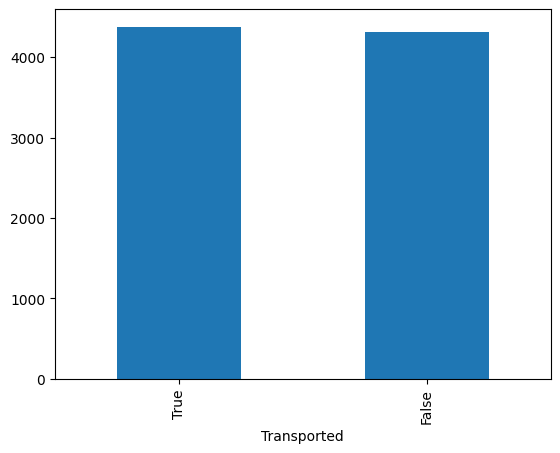

In [127]:
# 전송 비율 그래프로 시각화
plot_df = train_df.Transported.value_counts()
plot_df.plot(kind="bar")

## 1. 동면 여부(CryoSleep)

In [125]:
# 동면 인원수 확인
train_df['CryoSleep'].value_counts()

CryoSleep
False    5439
True     3037
Name: count, dtype: int64

In [55]:
# 동면 여부별로 전송 비율
sleep_ratio = train_df.groupby('CryoSleep')['Transported'].value_counts(normalize=True).unstack()
print(sleep_ratio)

Transported     False     True 
CryoSleep                      
False        0.671079  0.328921
True         0.182417  0.817583


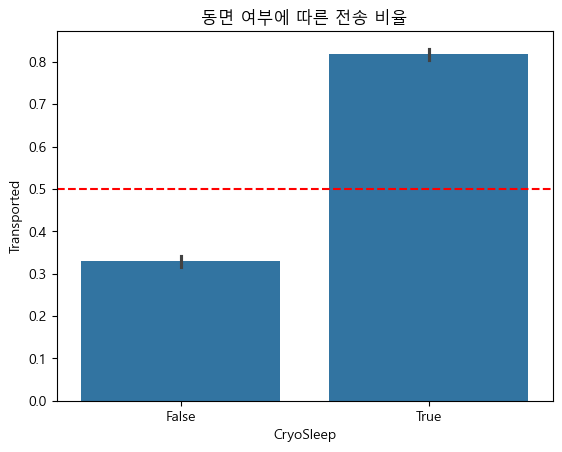

In [157]:
# 동면 여부에 따른 전송 비율 시각화
sns.barplot(data=train_df, x='CryoSleep', y='Transported')
plt.title('동면 여부에 따른 전송 비율')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

동면하고 있는 사람이 전송될 확률은 81%로 매우 높고, 깨어나 있는 사람이 전송될 확률은 32%로 낮은 것을 알 수 있습니다.

## 2. 승객 나이(Age)

In [133]:
# 나이대 변수 만들기
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=range(0, 81, 4))

# 나이대별 전송 비율 계산 
age_ratio = train_df.groupby('AgeGroup')['Transported'].value_counts(normalize=True).unstack()

# 결과 출력
print(age_ratio)

Transported     False     True 
AgeGroup                       
(0, 4]       0.256944  0.743056
(4, 8]       0.409357  0.590643
(8, 12]      0.378698  0.621302
(12, 16]     0.449225  0.550775
(16, 20]     0.510496  0.489504
(20, 24]     0.559934  0.440066
(24, 28]     0.496625  0.503375
(28, 32]     0.552826  0.447174
(32, 36]     0.500741  0.499259
(36, 40]     0.536424  0.463576
(40, 44]     0.494908  0.505092
(44, 48]     0.491329  0.508671
(48, 52]     0.552239  0.447761
(52, 56]     0.524590  0.475410
(56, 60]     0.456790  0.543210
(60, 64]     0.495575  0.504425
(64, 68]     0.527273  0.472727
(68, 72]     0.538462  0.461538
(72, 76]     0.611111  0.388889
(76, 80]     0.750000  0.250000


C:\Users\User\AppData\Local\Temp\ipykernel_1588\1735654504.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_ratio = train_df.groupby('AgeGroup')['Transported'].value_counts(normalize=True).unstack()


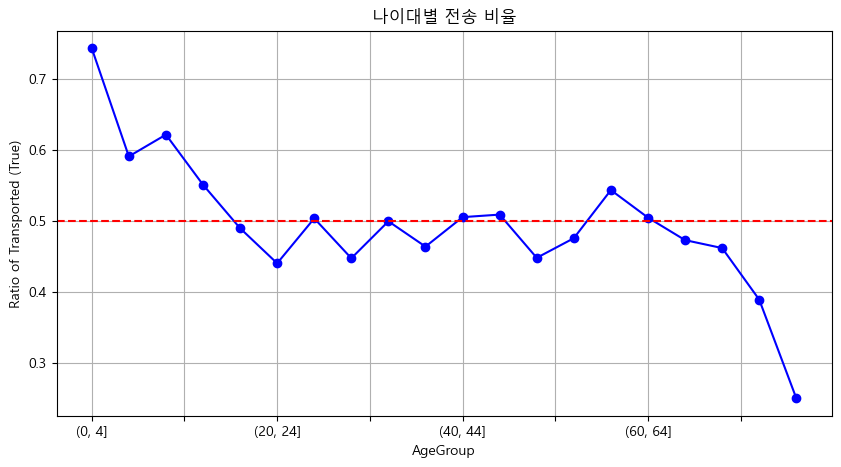

In [158]:
# 시각화
age_ratio[True].plot(kind='line', marker='o', figsize=(10, 5), color='blue')
plt.axhline(0.5, color='red', linestyle='--')
plt.title('나이대별 전송 비율')
plt.ylabel('Ratio of Transported (True)')
plt.grid(True)
plt.show()

0~4세까지 전송 확률이 74%로 평균보다 매우 높은 것을 알 수 있고, 70세 이상부터는 40%대부터 25%대까지 떨어져 매우 낮은 것을 알 수 있습니다.

0~4세는 Baby라는 영유아층 그룹을 따로 만들겠습니다.

In [102]:
# 전송 확률이 압도적으로 높은 영유아층 만들기
train_df['Baby'] = (train_df['Age'] <= 4).astype(int)

4~12세는 Child 그룹으로 만들겠습니다.

In [188]:
train_df['Child'] = ((train_df['Age'] > 4) & (train_df['Age'] <= 12)).astype(int)

이번엔 나이별 동면 비율을 알아보겠습니다.

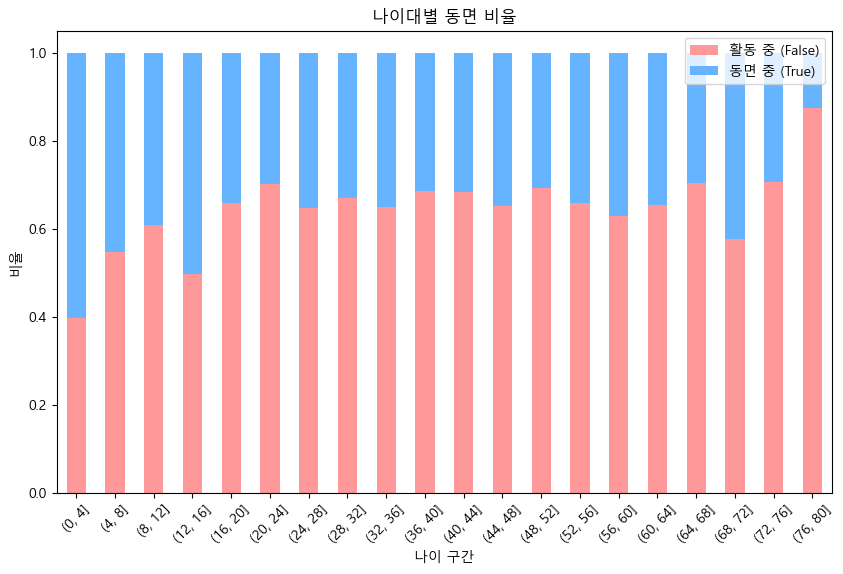

In [195]:
# 나이 구간별 동면 여부 데이터 집계 (비율로 계산)
age_cryo_dist = train_df.groupby('AgeGroup', observed=False)['CryoSleep'].value_counts(normalize=True).unstack()

# 3. 시각화
age_cryo_dist.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999', '#66b3ff'])

plt.title('나이대별 동면 비율')
plt.xlabel('나이 구간')
plt.ylabel('비율')
plt.legend(['활동 중 (False)', '동면 중 (True)'], loc='upper right')
plt.xticks(rotation=45)
plt.show()

이번에는 나이대별로 동면 여부별 전송 비율을 알아보겠습니다.

In [196]:
# 기본값은 성인 활동(Adult_Active)으로 세팅
train_df['Age_Cryo'] = 'Adult_Active'

# 동면 중인 성인 그룹(Adult_sleep)만들기
train_df.loc[(train_df['Baby'] == 0) & (train_df['Child'] == 0) & (train_df['CryoSleep'] == True), 'Age_Cryo'] = 'Adult_Sleep'

# 어린이(Child) 그룹 추가
train_df.loc[(train_df['Child'] == 1) & (train_df['CryoSleep'] == True), 'Age_Cryo'] = 'Child_Sleep'
train_df.loc[(train_df['Child'] == 1) & (train_df['CryoSleep'] == False), 'Age_Cryo'] = 'Child_Active'

# 아기(Baby) 그룹 추가
train_df.loc[(train_df['Baby'] == 1) & (train_df['CryoSleep'] == True), 'Age_Cryo'] = 'Baby_Sleep'
train_df.loc[(train_df['Baby'] == 1) & (train_df['CryoSleep'] == False), 'Age_Cryo'] = 'Baby_Active'

age_cryo_ratio = train_df.groupby('Age_Cryo')['Transported'].mean().sort_values(ascending=False)
print(age_cryo_ratio)

Age_Cryo
Adult_Sleep     0.830827
Baby_Sleep      0.780591
Baby_Active     0.761682
Child_Sleep     0.628571
Child_Active    0.593750
Adult_Active    0.308190
Name: Transported, dtype: float64


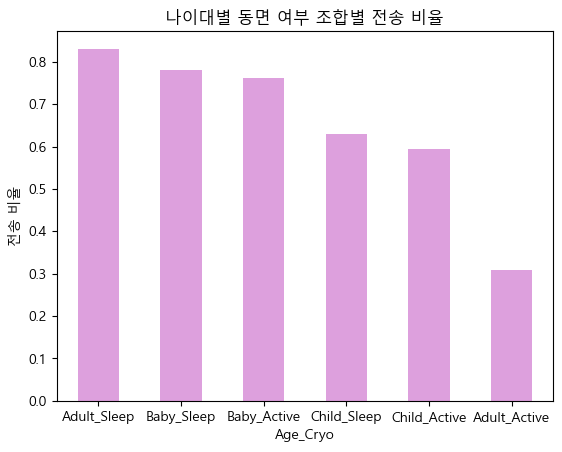

In [197]:
# 시각화
age_cryo_ratio.plot(kind='bar', color='plum', rot=0)
plt.title('나이대별 동면 여부 조합별 전송 비율')
plt.ylabel('전송 비율')
plt.show()

성인은 동면했을 때 83%로 전송 확률이 매우 높지만 깨어 있을 때는 30%로 낮다는 것을 알 수 있습니다.<br> 반면에 0~4세 Baby그룹은 78%,76%로 동면 중이나 동면 중이지 않을 때나 거의 차이 없이 전송 확률이 매우 높다는 것을 알 수 있습니다.<br>4~12세 Child그룹 또한 62%, 59%로 동면 여부가 차이가 거의 없으며 전송 확률이 평균보다는 높다는 것을 알 수 있습니다.

## 3. 지출 금액(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)

In [117]:
# 지출 항목 하나로 합치기
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# 총 지출액 합산
train_df['TotalSpending'] = train_df[spending_cols].sum(axis=1)

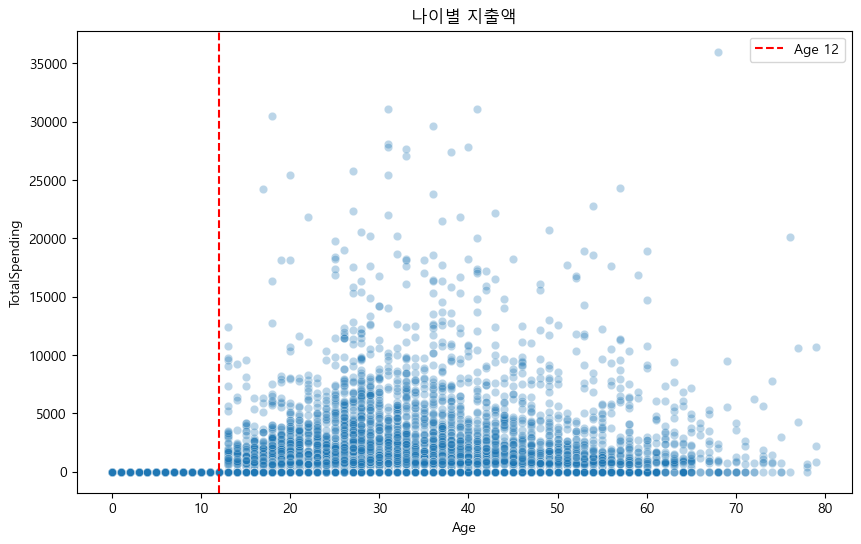

In [160]:
# 나이와 지출의 상관관계 산점도로 확인
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='Age', y='TotalSpending', alpha=0.3)
plt.axvline(12, color='red', linestyle='--', label='Age 12')
plt.title('나이별 지출액')
plt.legend()
plt.show()

In [161]:
# 0세부터 20세까지, 나이별 평균 지출액 확인
age_spending = train_df.groupby('Age')['TotalSpending'].mean().head(20)
print(age_spending)

Age
0.0        0.000000
1.0        0.000000
2.0        0.000000
3.0        0.000000
4.0        0.000000
5.0        0.000000
6.0        0.000000
7.0        0.000000
8.0        0.000000
9.0        0.000000
10.0       0.000000
11.0       0.000000
12.0       0.000000
13.0    1115.304965
14.0     663.449275
15.0     772.329032
16.0     707.884354
17.0     909.911392
18.0    1092.787500
19.0     970.873720
Name: TotalSpending, dtype: float64


0~12세까지는 지출이 없고 13세부터는 지출이 생김을 알 수 있습니다.

0~12세는 지출이 0이므로 데이터 정제를 위해 Baby&Child 그룹을 만들겠습니다.

In [183]:
train_df['Baby&Child'] = (train_df['Age'] <= 12).astype(int)

Baby, Child 변수가 잘 만들어졌는지 확인해 보겠습니다

In [184]:
print(train_df[['Age', 'Baby', 'Baby&Child']].head(15))

     Age  Baby  Baby&Child
0   39.0     0           0
1   24.0     0           0
2   58.0     0           0
3   33.0     0           0
4   16.0     0           0
5   44.0     0           0
6   26.0     0           0
7   28.0     0           0
8   35.0     0           0
9   14.0     0           0
10  34.0     0           0
11  45.0     0           0
12  32.0     0           0
13  48.0     0           0
14  28.0     0           0


In [185]:
print(train_df[['Age', 'Baby', 'Baby&Child']].sort_values(by='Age').head(15))

      Age  Baby  Baby&Child
1763  0.0     1           1
774   0.0     1           1
773   0.0     1           1
5982  0.0     1           1
771   0.0     1           1
8650  0.0     1           1
5988  0.0     1           1
5993  0.0     1           1
2813  0.0     1           1
6006  0.0     1           1
5976  0.0     1           1
732   0.0     1           1
6052  0.0     1           1
2870  0.0     1           1
157   0.0     1           1


이번엔 지출 구간별 전송 비율을 알아보겠습니다.

In [ ]:
# 구간에 붙일 이름 리스트 만들기
my_labels = ['0원 구간', '중간 지출 구간', '고액 지출 구간']

# 구간 나누기
train_df['SpendingGroup'] = pd.qcut(train_df['TotalSpending'], q=5, duplicates='drop', labels=my_labels)

# 그룹화해서 전송 비율 계산
spend_group_ratio = train_df.groupby('SpendingGroup', observed=False)['Transported'].value_counts(normalize=True).unstack()
print(spend_group_ratio)

Transported       False     True 
SpendingGroup                    
0원 구간          0.361771  0.638229
중간 지출 구간       0.717491  0.282509
고액 지출 구간       0.679126  0.320874


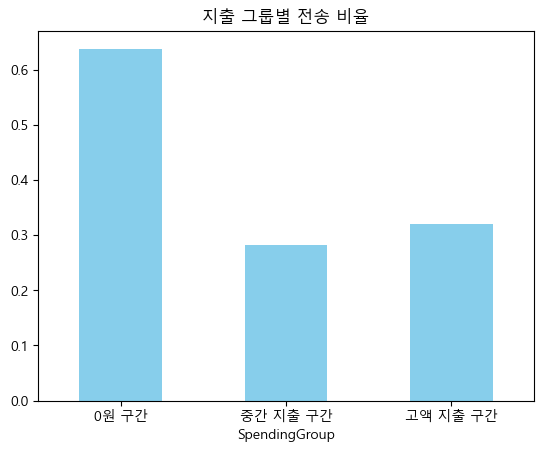

In [152]:
# 시각화
spend_group_ratio[True].plot(kind='bar', color='skyblue', rot=0)
plt.title('지출 그룹별 전송 비율')
plt.show()

한 푼도 쓰지 않은 사람이 전송될 확률이 63%로 높습니다. 돈을 쓴 그룹인 중간 지출 구간과 고액 지출 구간은 28%와 32%로 전송 확률이 낮다는 것을 알 수 있습니다.

In [199]:
# 지출이 0원인 사람들만 추출
zero_spenders = train_df[train_df['TotalSpending'] == 0]

# 그 안에서 동면 여부에 따른 전송 비율 확인
zero_cryo_analysis = zero_spenders.groupby('CryoSleep', observed=False)['Transported'].mean()
print(zero_cryo_analysis)

CryoSleep
False    0.615830
True     0.817583
Name: Transported, dtype: float64


In [201]:
zero_cryo_counts = zero_spenders['CryoSleep'].value_counts(normalize=True)

print("--- 0원 지출자 내부의 동면 여부 비중 ---")
print(zero_cryo_counts)

--- 0원 지출자 내부의 동면 여부 비중 ---
CryoSleep
True     0.85429
False    0.14571
Name: proportion, dtype: float64


동면 중인 사람이 전송될 확률이 82%인데 0원 구간인 사람이 전송될 확률은 63%이므로 동면 중이지 않음에도 한 푼도 쓰지 않은 사람이 있고, 아기는 돈을 쓸 수 없으므로 동면 중이지 않은 아기가 그 대부분임을 추측할 수 있습니다.

## 4. 출발 행성 (HomePlanet)

In [123]:
# 행성별 인원수 확인
print(train_df['HomePlanet'].value_counts())


HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64


Transported     False     True 
HomePlanet                     
Earth        0.576054  0.423946
Europa       0.341154  0.658846
Mars         0.476976  0.523024


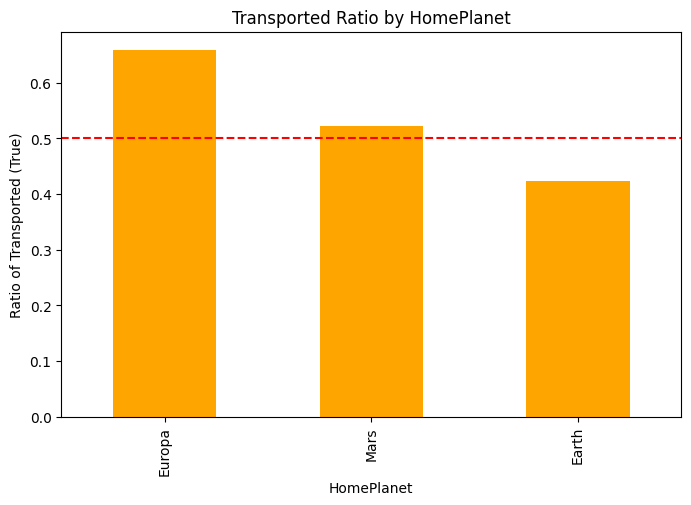

In [129]:
# 행성별 전송 비율
planet_ratio = train_df.groupby('HomePlanet')['Transported'].value_counts(normalize=True).unstack()
print(planet_ratio)

# 시각화 (막대 그래프)
planet_ratio[True].sort_values(ascending=False).plot(kind='bar', figsize=(8, 5), color='orange')
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Transported Ratio by HomePlanet')
plt.ylabel('Ratio of Transported (True)')
plt.show()

유로파 행성 출신자가 65%로 전송 확률이 높은 것을 알 수 있습니다.

이번에는 행성별 지출액을 보겠습니다.

In [135]:
# 행성별 평균 지출액 비교
planet_spending = train_df.groupby('HomePlanet')['TotalSpending'].mean().sort_values(ascending=False)
print("행성별 평균 지출:\n", planet_spending)

# 행성별 VIP 인원수 확인
planet_vip = train_df.groupby('HomePlanet')['VIP'].sum()
print("\n행성별 VIP 인원:\n", planet_vip)

행성별 평균 지출:
 HomePlanet
Europa    3451.624589
Mars      1051.256964
Earth      673.337462
Name: TotalSpending, dtype: float64

행성별 VIP 인원:
 HomePlanet
Earth       0
Europa    131
Mars       63
Name: VIP, dtype: object


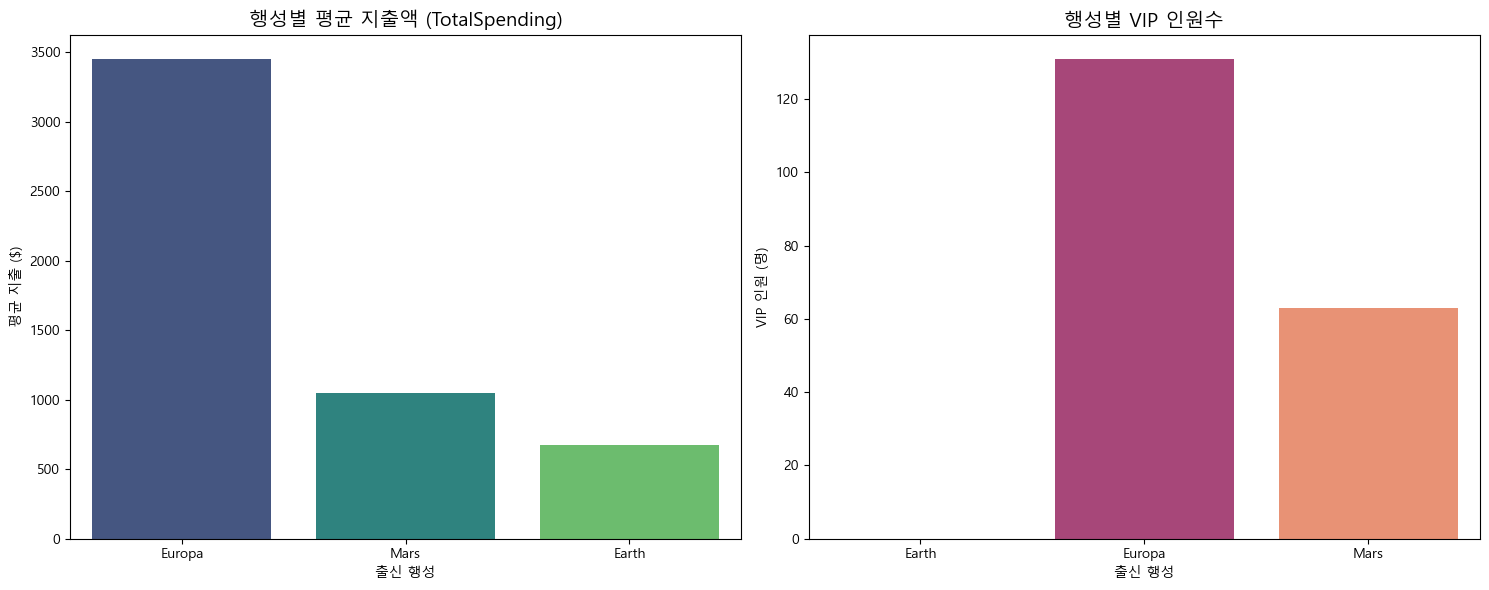

In [224]:
# 시각화 설정
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 행성별 평균 지출액 막대 그래프
sns.barplot(x=planet_spending.index, y=planet_spending.values, ax=axes[0], palette='viridis', hue=planet_spending.index, legend=False)
axes[0].set_title('행성별 평균 지출액 (TotalSpending)', fontsize=14)
axes[0].set_ylabel('평균 지출 ($)')
axes[0].set_xlabel('출신 행성')

# 2. 행성별 VIP 인원수 막대 그래프
sns.barplot(x=planet_vip.index, y=planet_vip.values, ax=axes[1], palette='magma', hue=planet_spending.index, legend=False)
axes[1].set_title('행성별 VIP 인원수', fontsize=14)
axes[1].set_ylabel('VIP 인원 (명)')
axes[1].set_xlabel('출신 행성')

plt.tight_layout()
plt.show()

행성별 평균 지출을 통해 유로파 행성이 다른 행성보다 월등히 높다는 것을 알 수 있습니다.<br>행성별 VIP인원 또한 유로파 행성이 가장 높으므로 유로파 행성은 다른 행성보다 부유한 행성임을 알 수 있습니다.

이번에는 행성별 동면 비율을 확인해 보겠습니다

In [ ]:
# 행성별 동면 비율 확인
cryo_by_planet = train_df.groupby('HomePlanet')['CryoSleep'].mean()
print("행성별 동면 비율:\n", cryo_by_planet)

# 유로파 주민의 동면 여부별 전송률 확인
europa_only = train_df[train_df['HomePlanet'] == 'Europa']
europa_cyro = europa_only.groupby('CryoSleep')['Transported'].mean()
print("\n유로파 내부 동면 여부별 전송률:\n", europa_cyro)

# 지구 주민의 동면 여부별 전송률 확인
earth_only = train_df[train_df['HomePlanet'] == 'Earth']
earth_cyro = earth_only.groupby('CryoSleep')['Transported'].mean()
print("\n지구 내부 동면 여부별 전송률:\n", earth_cyro)

# 화성 주민의 동면 여부별 따른 전송률 확인
mars_only = train_df[train_df['HomePlanet'] == 'Mars']
mars_cyro = mars_only.groupby('CryoSleep')['Transported'].mean()
print("\n화성 내부 동면 여부별 전송률:\n", mars_cyro)

행성별 동면 비율:
 HomePlanet
Earth     0.307932
Europa     0.43946
Mars       0.38986
Name: CryoSleep, dtype: object

유로파 내부 동면 여부별 전송률:
 CryoSleep
False    0.400172
True     0.989023
Name: Transported, dtype: float64

지구 내부 동면 여부별 전송률:
 CryoSleep
False    0.320992
True     0.656295
Name: Transported, dtype: float64

화성 내부 동면 여부별 전송률:
 CryoSleep
False    0.276982
True     0.911809
Name: Transported, dtype: float64


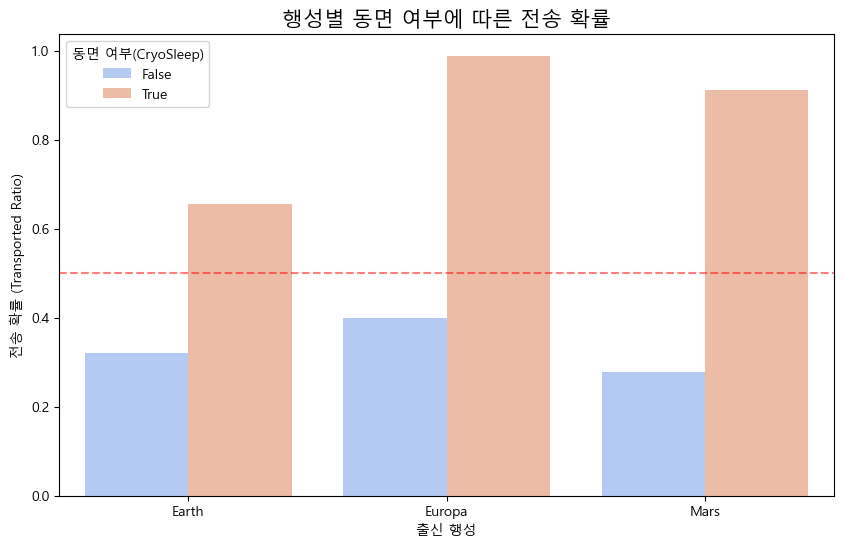

In [227]:
# 시각화를 위해 데이터 재구성
# 행성별 + 동면여부별 전송률 평균 계산
planet_cryo_ratio = train_df.groupby(['HomePlanet', 'CryoSleep'])['Transported'].mean().reset_index()

# 그래프로 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=planet_cryo_ratio, x='HomePlanet', y='Transported', hue='CryoSleep', palette='coolwarm')

# 기준선 추가 - 전송 확률 50% 지점
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.title('행성별 동면 여부에 따른 전송 확률', fontsize=15)
plt.ylabel('전송 확률 (Transported Ratio)')
plt.xlabel('출신 행성')
plt.legend(title='동면 여부(CryoSleep)', loc='upper left')

plt.show()

행성별 동면 비율은 유로파가 제일 높았습니다. 동면에는 돈이 들 것이므로 앞서 항성별 지출액으로 봤을 때, 가장 부유했던 유로파>화성>지구 순으로 동면 비율이 높은 것을 알 수 있습니다.

행성별 동면 여부에 따른 전송률을 보면 유로파는 True 98%, False 40%로 유로파의 동면자들은 거의 다 전송 되었음을 알 수 있고, 화성은 True 91%, False 27%로 화성의 동면자들 역시 대부분 전송 되었음을 알 수 있다. 지구는 True 65%, False 32%로 지구의 동면자들은 평균보다는 높지만 유로파나 화성보다는 낮은 수치인 65%로 전송되었다.

돈이 많은 행성일수록 전송률이 높고, 돈이 많은 행성의 동면자는 전송률이 대폭 상승하므로 돈이 많은 행성의 객실과 그렇지 않은 행성의 객실의 위치에 따른 차이라고 추측해볼 수 있을 것 같습니다. 따라서 다음에는 객실 번호(Cabin)을 살펴보겠습니다.

## 5. Deck(층수), Side(좌우방향)

In [273]:
# Cabin 컬럼을 층(Deck), 번호(Num), 방향(Side)으로 분리
# P는 Port(좌현), S는 Starboard(우현)를 의미합니다.
train_df[['Deck', 'Num', 'Side']] = train_df['Cabin'].str.split('/', expand=True)
print(train_df['Deck'].value_counts())

Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64


In [277]:
print(train_df['Side'].value_counts())

Side
S    4288
P    4206
Name: count, dtype: int64


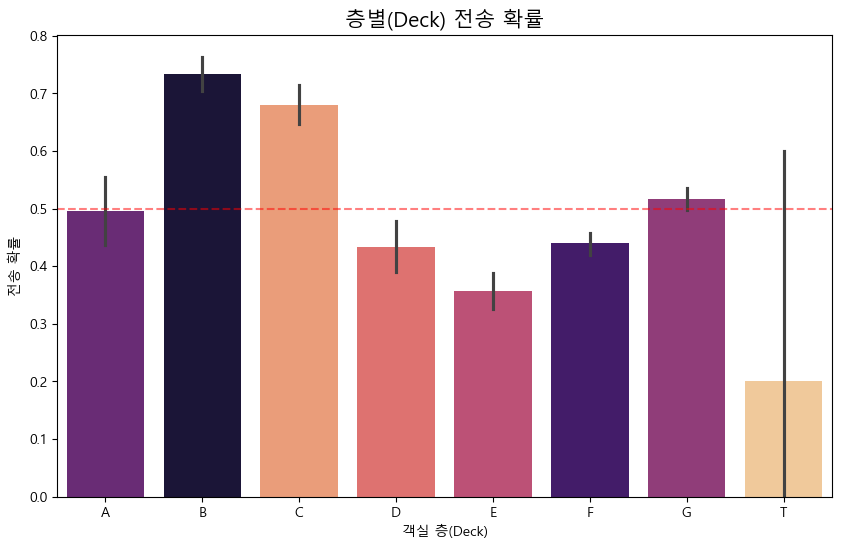

In [306]:
# 그래프로 시각화
plt.figure(figsize=(10, 6))

# Deck별 전송률 그래프로 그리기
deck_order = sorted(train_df['Deck'].dropna().unique())
sns.barplot(data=train_df, x='Deck', y='Transported', order=deck_order, palette='magma', hue='Deck', legend=False)
plt.title('층별(Deck) 전송 확률', fontsize=15)
plt.ylabel('전송 확률')
plt.xlabel('객실 층(Deck)')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.show()

--- 좌우(P/S) 방향별 전송 확률 ---
Side
P    0.451260
S    0.555037
Name: Transported, dtype: float64


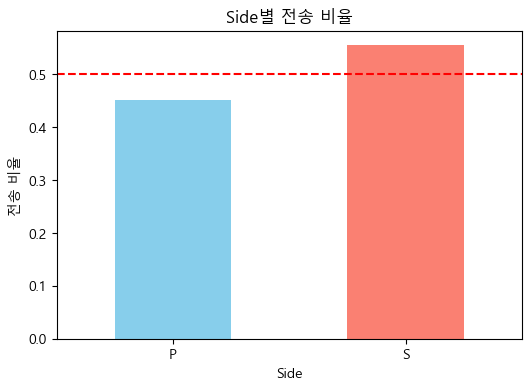

In [284]:
# Side별 전송 확률 계산
side_analysis = train_df.groupby('Side')['Transported'].mean()
print("--- 좌우(P/S) 방향별 전송 확률 ---")
print(side_analysis)

# 시각화로 한눈에 비교
side_analysis.plot(kind='bar', color=['skyblue', 'salmon'], figsize=(6, 4), rot=0)
plt.title('Side별 전송 비율')
plt.ylabel('전송 비율')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

Deck별로 보면, B와 C층이 전송률이 매우 높고, T층은 매우 낮은 것을 알 수 있습니다.<br> Side별로 보면, P(좌현) 45%, S(우현) 55%로 유의미하게 S(우현)가 높은 것을 알 수 있습니다.

이번에는 행성별로 어떤 층수(Deck)에 머물렀는지 살펴보겠습니다.

In [304]:
# Deck 정보 추출
if 'Deck' not in train_df.columns:
    train_df['Deck'] = train_df['Cabin'].str.split('/', expand=True)[0]

# 행성별 Deck 거주 현황
planet_deck = pd.crosstab(train_df['HomePlanet'], train_df['Deck'], normalize='index')
print(planet_deck)

Deck               A         B         C         D         E         F  \
HomePlanet                                                               
Earth       0.000000  0.000000  0.000000  0.000000  0.087641  0.358110   
Europa      0.121739  0.370048  0.354589  0.089855  0.061836  0.000000   
Mars        0.000000  0.000000  0.000000  0.163763  0.191638  0.644599   

Deck               G         T  
HomePlanet                      
Earth       0.554249  0.000000  
Europa      0.000000  0.001932  
Mars        0.000000  0.000000  


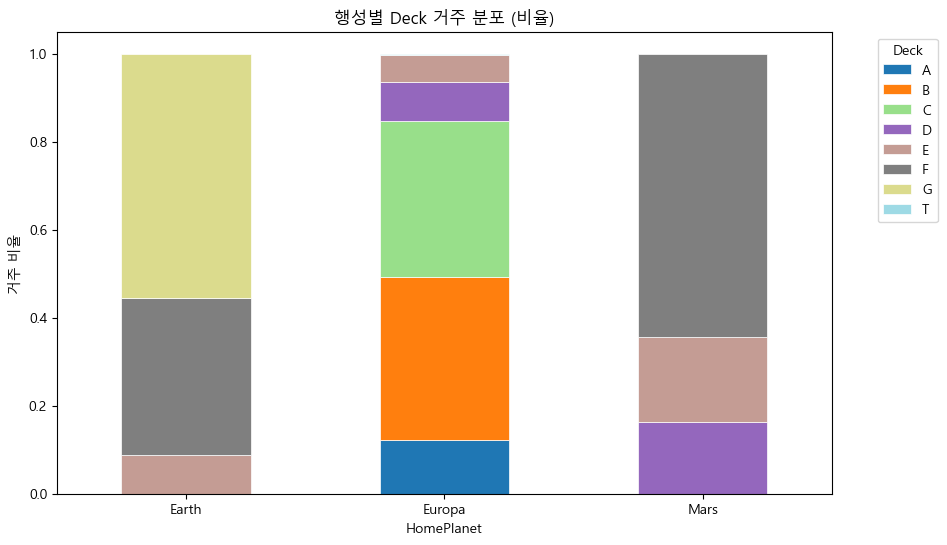

In [274]:
# 그래프로 시각화
# planet_deck.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', rot=0)
planet_deck.plot(kind='bar', stacked=True, figsize=(10, 6), 
                 colormap='tab20', edgecolor='white', linewidth=0.5, rot=0)
plt.title('행성별 Deck 거주 분포 (비율)')
plt.ylabel('거주 비율')
plt.legend(title='Deck', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

이번엔 층(Deck)별 방향(Side)에 따른 전송 확률을 보겠습니다.

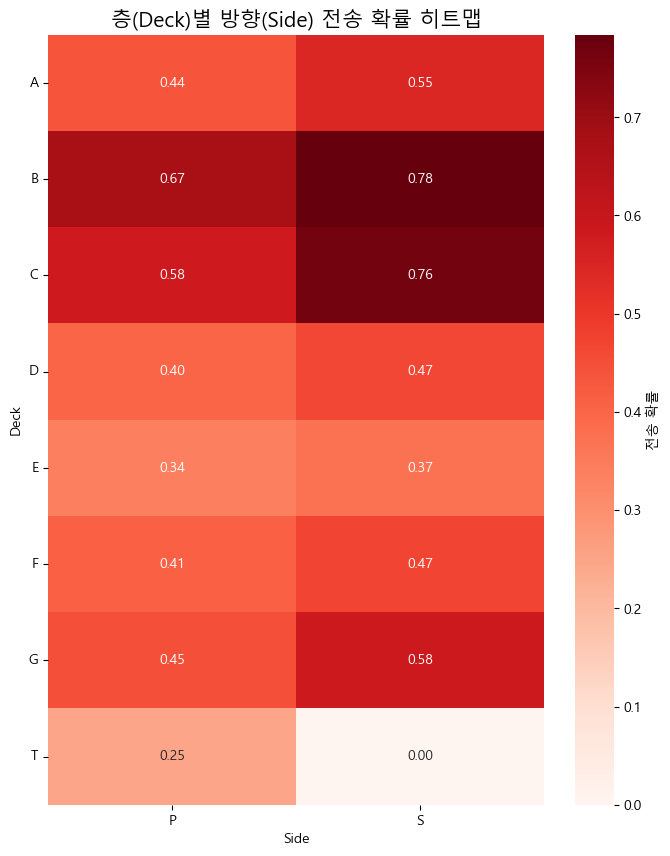

In [370]:
# Deck과 Side별 전송 확률 교차표 만들기
deck_side_pivot = train_df.pivot_table(index='Deck', columns='Side', values='Transported', aggfunc='mean')

# 히트맵으로 시각화
plt.figure(figsize=(8, 10))
sns.heatmap(deck_side_pivot, annot=True, fmt='.2f', cmap='Reds', cbar_kws={'label': '전송 확률'})
plt.title('층(Deck)별 방향(Side) 전송 확률 히트맵', fontsize=15)
plt.yticks(rotation=0)
plt.show()

행성별 거주지 분포:<br>지구(Earth) 승객은 주로 저층부인 G층(최다)과 F층에 거주하며, E층에는 소수만이 머물렀습니다.<br>
유로파(Europa) 승객은 B, C층에 집중적으로 분포해 있으며, A, D, E층에는 소수가 거주했고, T층에 거주한 인원은 5명으로 유로파 행성에서도 돈이 가장 많은 극소수만이 머물렀음을 추측해볼 수 있습니다.<br>
화성(Mars) 승객은 F층을 주 거주지로 삼았으며, E와 D층에 일부가 분산 거주했습니다.

사고 원인 분석:<br> 유로파 승객의 전송 확률은 약 65%로 타 행성 대비 매우 높습니다.<br>
앞서 확인한 그래프에서 유로파 승객의 주 거주지인 B층과 C층의 전송 확률(최대 78%)이 압도적으로 높게 나타난 점을 미루어 볼 때, B·C층 구역이 시공간 이상 현상의 직격탄을 맞은 핵심 피해 지역임을 알 수 있습니다.

## 6. VIP

In [308]:
# VIP별 전송 확률
print("--- VIP 여부별 전송 확률 ---")
print(train_df.groupby('VIP')['Transported'].mean())

# VIP와 행성의 관계
print("\n--- VIP들의 고향 행성 ---")
print(pd.crosstab(train_df['HomePlanet'], train_df['VIP']))

--- VIP 여부별 전송 확률 ---
VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

--- VIP들의 고향 행성 ---
VIP         False  True 
HomePlanet              
Earth        4487      0
Europa       1958    131
Mars         1653     63


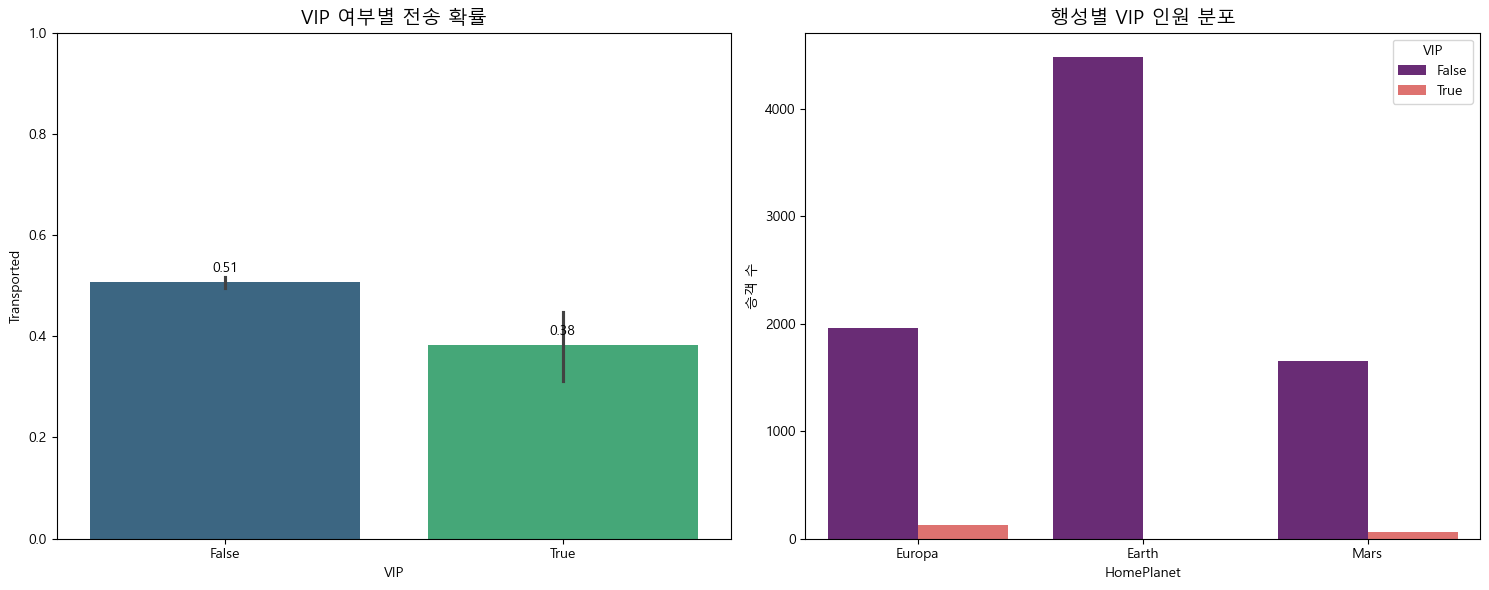

In [310]:
# 그래프 영역 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# VIP 여부에 따른 전송 확률
sns.barplot(data=train_df, x='VIP', y='Transported', ax=axes[0], palette='viridis', hue='VIP', legend=False)
axes[0].set_title('VIP 여부별 전송 확률', fontsize=14)
axes[0].set_ylim(0, 1)

# 확률 수치 표시
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# 행성별 VIP 분포
# 'VIP'가 True/False인 인원수를 행성별로 시각화
sns.countplot(data=train_df, x='HomePlanet', hue='VIP', ax=axes[1], palette='magma')
axes[1].set_title('행성별 VIP 인원 분포', fontsize=14)
axes[1].set_ylabel('승객 수')

plt.tight_layout()
plt.show()

In [319]:
# VIP 승객들만 골라내서 어느 Deck에 살았는지 확인하기
vip_deck_dist = pd.crosstab(train_df['Deck'], train_df['VIP'])
print("Deck별 VIP 거주 현황")
print(vip_deck_dist)

Deck별 VIP 거주 현황
VIP   False  True 
Deck              
A       215     35
B       725     42
C       687     41
D       438     31
E       846     15
F      2695     29
G      2493      0
T         5      0


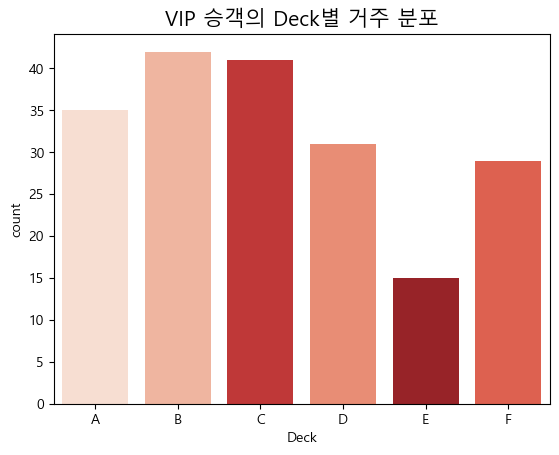

In [322]:
# VIP가 True인 데이터만 필터링
vip_only = train_df[train_df['VIP'] == True]

sns.countplot(
    data=vip_only, 
    x='Deck', 
    order=sorted(vip_only['Deck'].dropna().unique()), 
    palette='Reds',
    hue='Deck',     
    legend=False   
)

plt.title('VIP 승객의 Deck별 거주 분포', fontsize=15)
plt.show()

False 50.6%, True 38%이므로 VIP는 38%로 일반 승객에 비해 전송될 확률이 낮다는 것을 알 수 있습니다.<br> 위에서 B, C층(유로파 거주지)의 전송 확률이 70~80%였는데도 유로파 행성의 비율이 높은 VIP 승객의 전송 확률이 낮습니다.<br> 그러므로 VIP 구역은 같은 층이라도 조금 더 안전한 위치에 있었다, 혹은 VIP들은 사고 당시 구명정이나 안전 구역으로 빠르게 대피할 수 있는 권한이 있었다.등의 가설을 세울 수 있습니다.

## 7. 목적지 행성(Destination)

In [329]:
# 고향 행성별 목적지 행성
print("--- 고향 행성별 목적지 분포 ---")
print(pd.crosstab(train_df['HomePlanet'], train_df['Destination']))

--- 고향 행성별 목적지 분포 ---
Destination  55 Cancri e  PSO J318.5-22  TRAPPIST-1e
HomePlanet                                          
Earth                690            712         3101
Europa               886             19         1189
Mars                 193             49         1475


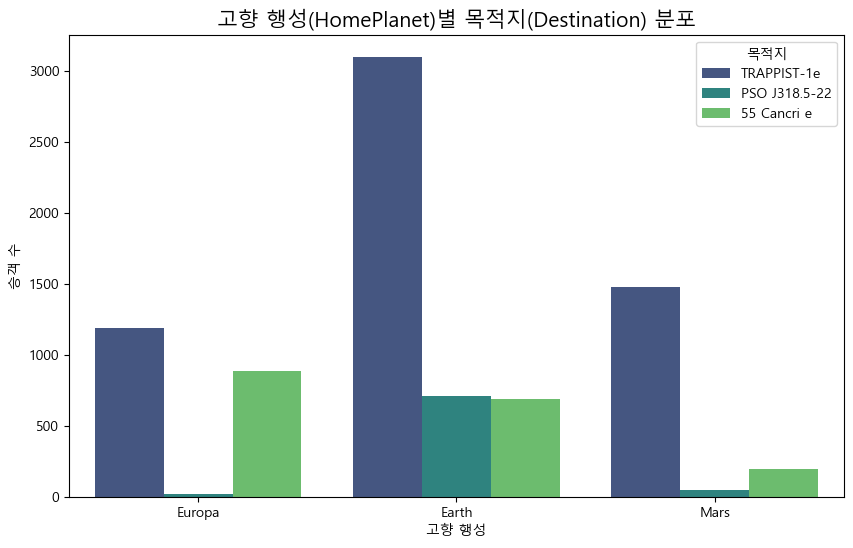

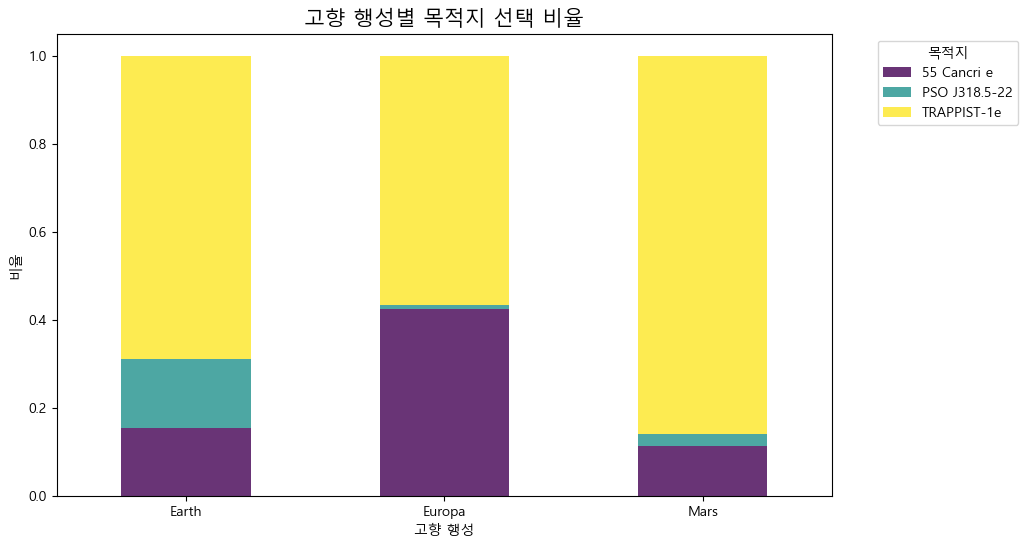

In [331]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='HomePlanet', hue='Destination', palette='viridis')

plt.title('고향 행성(HomePlanet)별 목적지(Destination) 분포', fontsize=15)
plt.xlabel('고향 행성')
plt.ylabel('승객 수')
plt.legend(title='목적지', loc='upper right')

plt.show()

# 비율로 확인하기 (어떤 행성 사람들이 특정 목적지를 더 선호하는가?)
planet_dest_pct = pd.crosstab(train_df['HomePlanet'], train_df['Destination'], normalize='index')
planet_dest_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', alpha=0.8)

plt.title('고향 행성별 목적지 선택 비율', fontsize=15)
plt.xlabel('고향 행성')
plt.ylabel('비율')
plt.xticks(rotation=0)
plt.legend(title='목적지', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

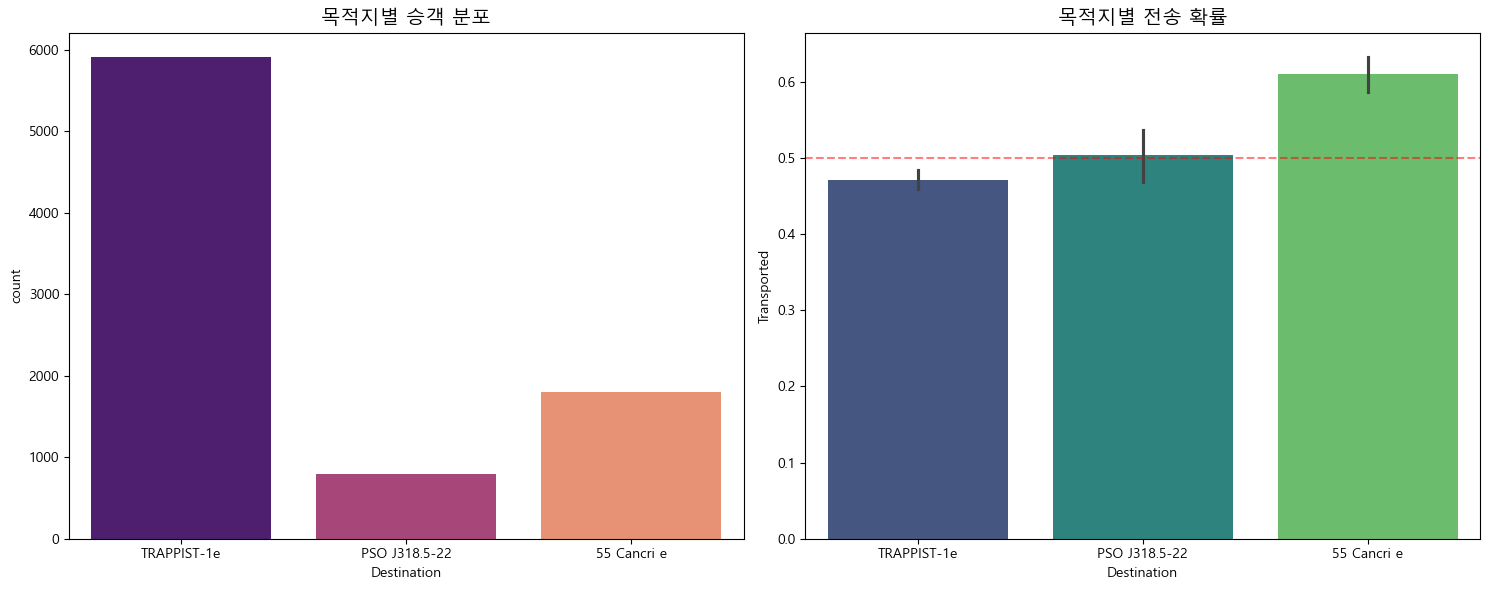

In [333]:
# 그래프 영역 설정
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# 목적지별 승객 수
sns.countplot(data=train_df, x='Destination', ax=axes[0], palette='magma', hue='Destination', legend=False)
axes[0].set_title('목적지별 승객 분포', fontsize=14)

# 목적지별 전송 확률 (어디로 가는 사람이 위험했나?)
sns.barplot(data=train_df, x='Destination', y='Transported', ax=axes[1], palette='viridis', hue='Destination', legend=False)
axes[1].set_title('목적지별 전송 확률', fontsize=14)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


55 Cancri e: 승객 수는 두 번째로 적지만, 전송 확률은 약 61%로 목적지 중 압도적으로 높습니다.<br>
TRAPPIST-1: 가장 많은 승객(약 6,000명)이 향하는 곳이지만 전송 확률은 50% 아래입니다.<br>
어디로 가느냐가 생사에 큰 영향을 미쳤으며, 특히 55 Cancri e 행을 선택한 승객들이 이번 사고의 주된 피해자인 것을 알 수 있습니다.<br>유로파 주민들은 주로 B, C층에 거주하고 히트맵 분석 결과, B, C층은 전송 확률(76~78%)이 가장 높은 '사고 직격탄' 구역이고 유로파 주민들은 다른 행성 주민들보다 55 Cancri e행 티켓을 훨씬 많이 끊었기 때문에 "55 Cancri e로 가려던 유로파 부유층 승객들이 하필 사고의 직격탄을 맞은 B, C층에 몰려 있었기 때문에 실종률이 높았다"라고 추정할 수 있습니다.

## 8. 그룹 크기(Group Size)

In [349]:
# PassengerId에서 Group ID(앞 4자리) 추출
train_df['Group'] = train_df['PassengerId'].str.split('_').str[0]

# 그룹별 인원수 계산하여 GroupSize 컬럼 생성
group_sizes = train_df.groupby('Group').size()
train_df['GroupSize'] = train_df['Group'].map(group_sizes)

# 그룹 크기별 전송 확률 수치 확인
print("--- 그룹 크기별 전송 확률 현황 ---")
print(train_df.groupby('GroupSize')['Transported'].mean())

--- 그룹 크기별 전송 확률 현황 ---
GroupSize
1    0.452445
2    0.538050
3    0.593137
4    0.640777
5    0.592453
6    0.614943
7    0.541126
8    0.394231
Name: Transported, dtype: float64


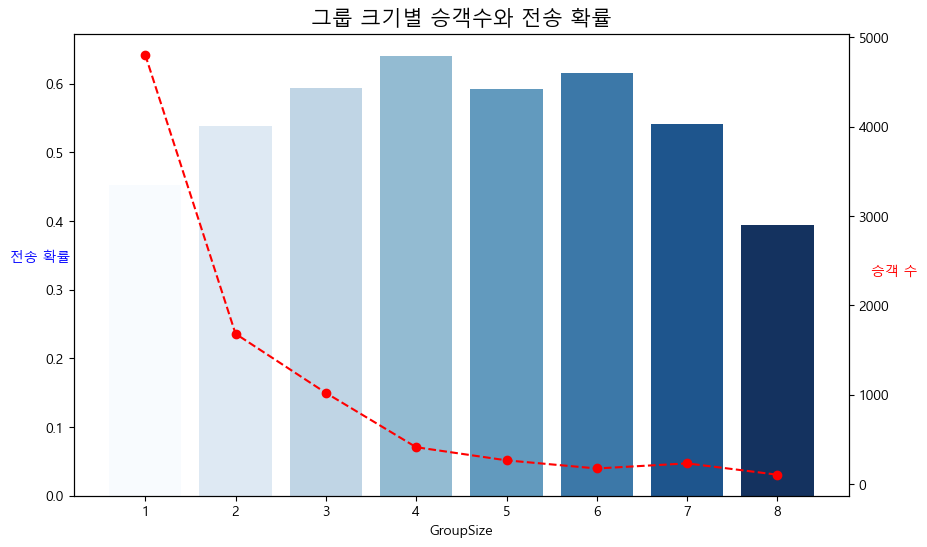

In [356]:
# 그래프로 시각화 - 그룹 크기별 승객수(Count)와 전송 확률(Ratio)을 동시에 확인
fig, ax1 = plt.subplots(figsize=(10, 6))

# 막대 그래프로 전송 확률 표시
sns.barplot(data=train_df, x='GroupSize', y='Transported', ax=ax1, 
            hue='GroupSize', palette='Blues', errorbar=None, legend=False)
ax1.set_ylabel('전송 확률', color='b', rotation=0)
ax1.set_title('그룹 크기별 승객수와 전송 확률', fontsize=15)

# 꺾은선 그래프로 해당 그룹 크기의 실제 승객 수 표시 (보조축 사용)
ax2 = ax1.twinx()
group_counts = train_df['GroupSize'].value_counts().sort_index()
ax2.plot(group_counts.index.astype(str), group_counts.values, color='red', marker='o', linestyle='--')
ax2.set_ylabel('승객 수', color='r', rotation=0)

plt.show()

혼자 온 승객(가장 많은 집단)은 전송 확률이 절반 미만입니다. 하지만 일행이 생기는 순간(2인 이상) 전송될 확률이 상승합니다.<br>4명 일행일 때 확률이 가장 높은데, 이는 객실 구조나 구역별 인원 배치와 관련이 있을 가능성이 크다고 추측할 수 있습니다.<br>가장 오른쪽 8명 그룹을 보면 확률이 39%로 뚝 떨어집니다. "8명이면 비교적 안전하다", "그룹 인원수가 많을 수록 전송될 확률이 낮다"라고 추측해볼 수 있지만, 빨간 점을 보면 표본 수가 적기 때문에 표본이 적어 생기는 특이값일 확률도 배제할 수 없을 것 같습니다.

## 9. 성씨(Surname) 분석 및 가족 규모(FamilySize)

In [359]:
# Name 컬럼에서 성(Surname) 추출 (이름이 없는 경우 'Unknown'으로 처리)
train_df['Surname'] = train_df['Name'].str.split().str[-1]

# 성씨별 인원수(FamilySize) 계산
family_counts = train_df['Surname'].value_counts()
train_df['FamilySize'] = train_df['Surname'].map(family_counts)

# 이름이 결측치인 경우 FamilySize를 1(최소단위)로 보정
train_df.loc[train_df['Surname'].isna(), 'FamilySize'] = 1

# 수치 확인
print("--- 성씨별 가족 규모(FamilySize)별 전송 확률 ---")
print(train_df.groupby('FamilySize')['Transported'].mean())

--- 성씨별 가족 규모(FamilySize)별 전송 확률 ---
FamilySize
1.0     0.556701
2.0     0.493750
3.0     0.534364
4.0     0.503906
5.0     0.509375
6.0     0.499037
7.0     0.481393
8.0     0.454044
9.0     0.482540
10.0    0.510000
11.0    0.505455
12.0    0.428571
13.0    0.461538
14.0    0.482143
15.0    0.600000
16.0    0.375000
18.0    0.388889
Name: Transported, dtype: float64


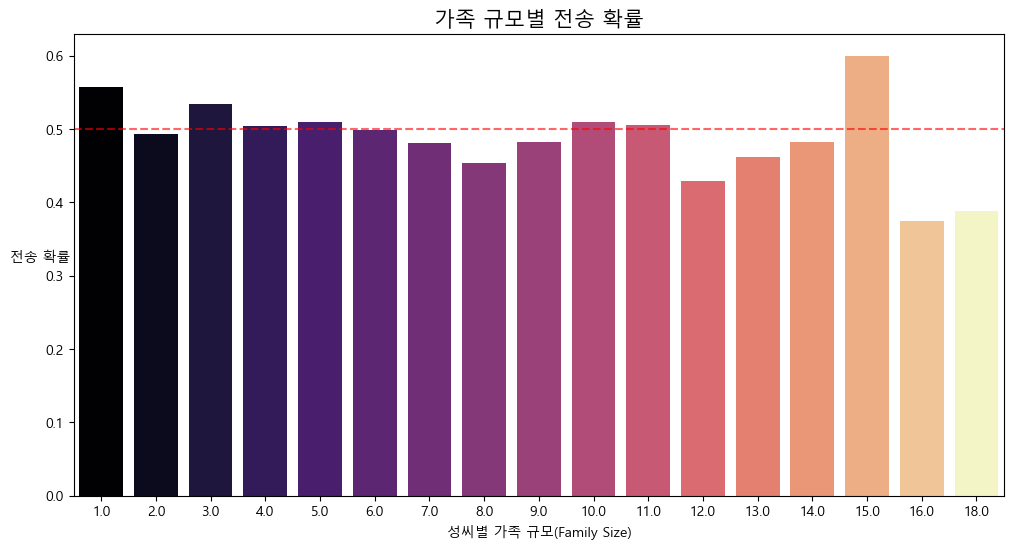

In [375]:
plt.figure(figsize=(12, 6))

# 가족 규모별 전송 확률 시각화
sns.barplot(data=train_df, x='FamilySize', y='Transported', 
            hue='FamilySize', palette='magma', legend=False, errorbar=None)

plt.axhline(0.5, color='red', linestyle='--', alpha=0.6)
plt.title('가족 규모별 전송 확률', fontsize=15)
plt.xlabel('성씨별 가족 규모(Family Size)')
plt.ylabel('전송 확률', rotation=0)
plt.show()

이 그래프는 예약 번호와 상관없이 우주선 전체에 같은 성을 가진 친척이 얼마나 있는가를 보여줍니다.<br>배에 나랑 같은 성을 가진 사람이 나뿐인 경우(1.0) 전송 확률이 55% 이상으로 꽤 높습니다.<br>가족 규모가 커질수록(2명~14명) 전송 확률이 조금씩 낮아지거나 50% 근처에서 머무는 경향을 보입니다.<br>15명 가족에서 확률이 60%로 급격히 치솟는데, 이는 해당 인원을 가진 특정 가문이 사고 당시 전송 장치와 매우 가까운 구역(예: 특정 Deck)에 밀집해 있었던 우연한 사례일 가능성이 큽니다.<br>배에 16, 18명 있는 거대 가문은 전송 확률이 40% 아래로 매우 낮습니다. 앞서 GroupSize 8명에서 나타난 현상과 비슷하게, "너무 큰 가족 집단은 전송될 확률이 낮다"는 결론을 뒷받침합니다.

<a id="preprocessing_section"></a>
# **데이터 전처리**

## 상관 관계 히트맵

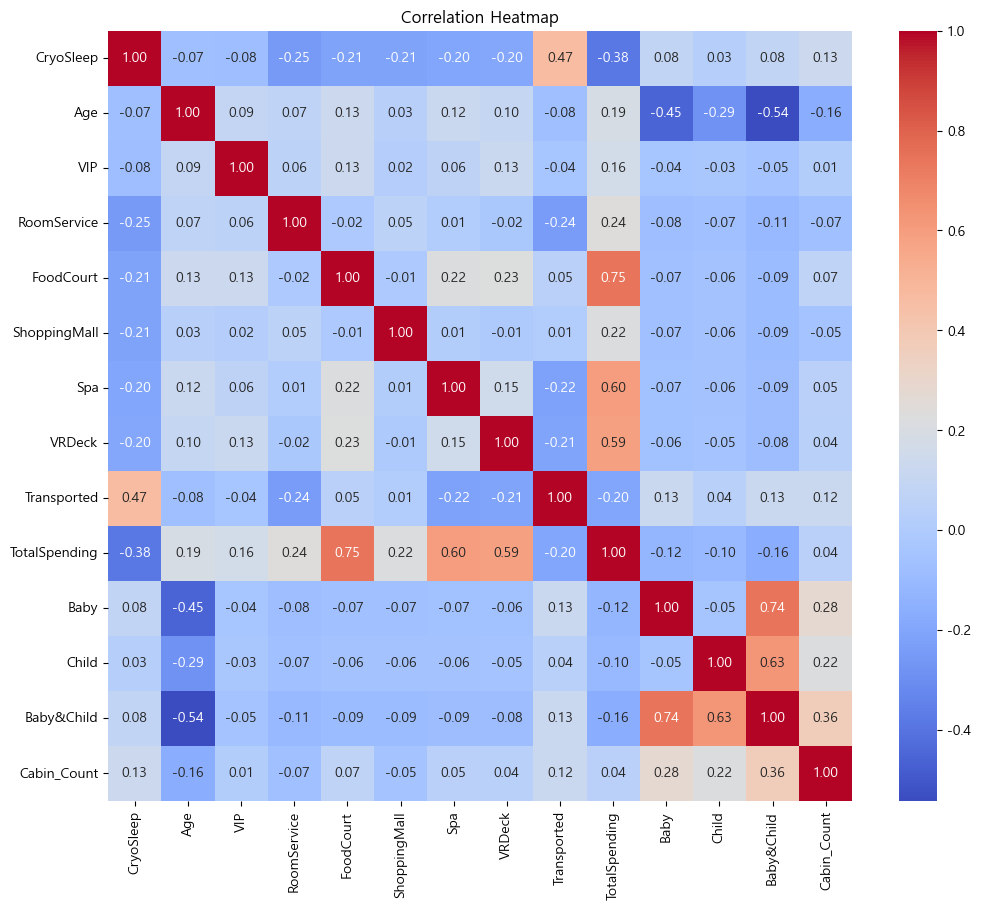

In [334]:
# 1. 분석을 위해 임시로 데이터 복사 및 전처리
h_df = train_df.copy()

# 2. 범주형 데이터를 숫자로 변환 (True/False -> 1/0)
h_df['CryoSleep'] = h_df['CryoSleep'].astype(float)
h_df['VIP'] = h_df['VIP'].astype(float)
h_df['Transported'] = h_df['Transported'].astype(float)

# 3. 지출 합계 변수 만들기
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
h_df['TotalSpending'] = h_df[spending_cols].sum(axis=1)

# 4. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(h_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()